# CIFAR-10 Dataset - Analiza skupa podataka

Ovaj notebook sadrzi:
- Ucitavanje podataka
- Ciscenje i validaciju
- Deskriptivnu statistiku
- Vizualizacije (distribucije, korelacije, nedostajuci podaci)
- Reproducibilne korake transformacije

### Import Biblioteka i inicijalizacija

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

#Import pipeline-a
from data_pipeline import CIFAR10DataPipeline

#Podesavanje stila za grafike
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

#Velicina figure
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Biblioteke ucitane")

Biblioteke ucitane


### Ucitavanje podataka pomocu Pipeline-a

In [2]:
# Inicijalizacija pipeline-a
pipeline = CIFAR10DataPipeline(data_dir='data/cifar-10')

# Učitavanje labela
train_df = pipeline.load_labels()

# Prikaz prvih redova
print("\nPregled podataka:")
display(train_df.head(10))

print(f"\nOblik DataFrame-a: {train_df.shape}")
print(f"Kolone: {list(train_df.columns)}")

Ucitavanje labela...
Ucitano 50000 labela

Pregled podataka:


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile
5,6,automobile
6,7,bird
7,8,horse
8,9,ship
9,10,cat



Oblik DataFrame-a: (50000, 2)
Kolone: ['id', 'label']


### Validacija podataka

In [3]:
#Pokretanje validacije
validation_results = pipeline.validate_data()

#Detaljni prikaz rezultata validacije
print("\n" + "="*60)
print("REZULTATI VALIDACIJE")
print("="*60)

for key, value in validation_results.items():
    if key != 'label_distribution':
        print(f"{key}: {value}")


Validacija podataka...
Provera postojanja slika...
Provera dimenzija slika...
Validacija završena
  - Ukupno labela: 50000
  - Jedinstvenih klasa: 10
  - Nedostajućih labela: 0
  - Duplikata ID-jeva: 0

REZULTATI VALIDACIJE
total_train_labels: 50000
unique_labels: 10
missing_labels: 0
duplicate_ids: 0
missing_images_sample: 0
sample_checked: 1000
image_dimensions: {'unique_dims': [(32, 32)], 'most_common': (32, 32)}


### Provera nedostajucih podataka

In [4]:
#Analiza nedostajucih vrednosti
missing_data = train_df.isnull().sum()

print("Nedostajuci podaci po kolonama:")
print(missing_data)

#Vizualizacija nedostajucih podataka
if missing_data.sum() > 0:
    plt.figure(figsize=(10,4))
    missing_data.plot(kind='bar', color='coral')
    plt.title('Nedostajuci podaci po kolonama', fontsize=14, fontweight='bold')
    plt.xlabel('Kolone')
    plt.ylabel('Broj nedostajucih vrednosti')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Nema nedostajucih podataka!")

Nedostajuci podaci po kolonama:
id       0
label    0
dtype: int64
Nema nedostajucih podataka!


### Ciscenje podataka

In [6]:
train_df_clean = pipeline.clean_data()

print(f"\nOblik nakon ciscenja: {train_df_clean.shape}")


Čišćenje podataka...
Čišćenje završeno
  - Uklonjeno redova: 0
  - Preostalo redova: 50000

Oblik nakon ciscenja: (50000, 2)


### Deskriptivna statistika

In [7]:
#Racunjanje statistike
stats = pipeline.get_descriptive_statistics()

#Prikay osnovnih informacija
print("\n" + "="*60)
print("DESKRIPTIVNA STATISTIKA")
print("="*60)

print(f"\nUkupno uzoraka: {stats['total_samples']}")
print(f"Broj klasa: {stats['num_classes']}")
print(f"\nStatistika po klasama:")
print(f"  - Minimum: {stats['min_class_count']}")
print(f"  - Maksimum: {stats['max_class_count']}")
print(f"  - Prosek: {stats['mean_class_count']:.2f}")
print(f"  - Std. devijacija: {stats['std_class_count']:.2f}")

# Tabela distribucije klasa
print("\nDistribucija klasa:")
class_dist_df = pd.DataFrame({
    'Klasa': list(stats['class_distribution'].keys()),
    'Broj uzoraka': list(stats['class_distribution'].values()),
    'Procenat (%)': [f"{v:.2f}" for v in stats['class_percentages'].values()]
})
class_dist_df = class_dist_df.sort_values('Broj uzoraka', ascending=False)
display(class_dist_df)


Računanje deskriptivne statistike...
Statistika izračunata
  - Ukupno uzoraka: 50000
  - Broj klasa: 10
  - Prosečan broj uzoraka po klasi: 5000.00

DESKRIPTIVNA STATISTIKA

Ukupno uzoraka: 50000
Broj klasa: 10

Statistika po klasama:
  - Minimum: 5000
  - Maksimum: 5000
  - Prosek: 5000.00
  - Std. devijacija: 0.00

Distribucija klasa:


,Klasa,Broj uzoraka,Procenat (%)
0,frog,5000,10.00
1,truck,5000,10.00
2,deer,5000,10.00
3,automobile,5000,10.00
4,bird,5000,10.00
5,horse,5000,10.00
6,ship,5000,10.00
7,cat,5000,10.00
8,dog,5000,10.00
9,airplane,5000,10.00


### Vizualizacija distribucije klasa

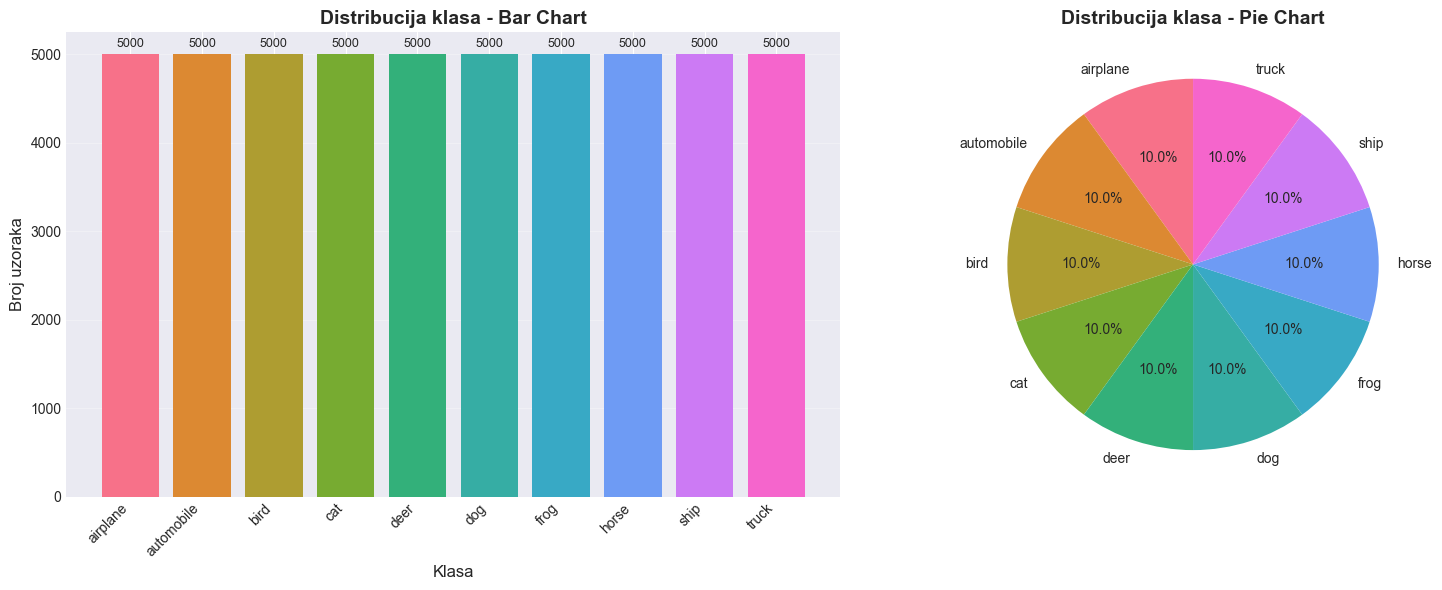

In [8]:
#Distribucija klasa - Bar plot
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Bar plot
class_counts = train_df_clean['label'].value_counts().sort_index()
axes[0].bar(range(len(class_counts)), class_counts.values, color=sns.color_palette("husl", len(class_counts)))
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Klasa', fontsize=12)
axes[0].set_ylabel('Broj uzoraka', fontsize=12)
axes[0].set_title('Distribucija klasa - Bar Chart', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

#Dodavanje vrednosti na stubove
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

#Pie chart
colors = sns.color_palette("husl", len(class_counts))
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Distribucija klasa - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("analysis_result/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Provera balansiranosti dataseta

Odnos najzastupljenije i najređe klase: 1.00
Dataset je dobro balansiran


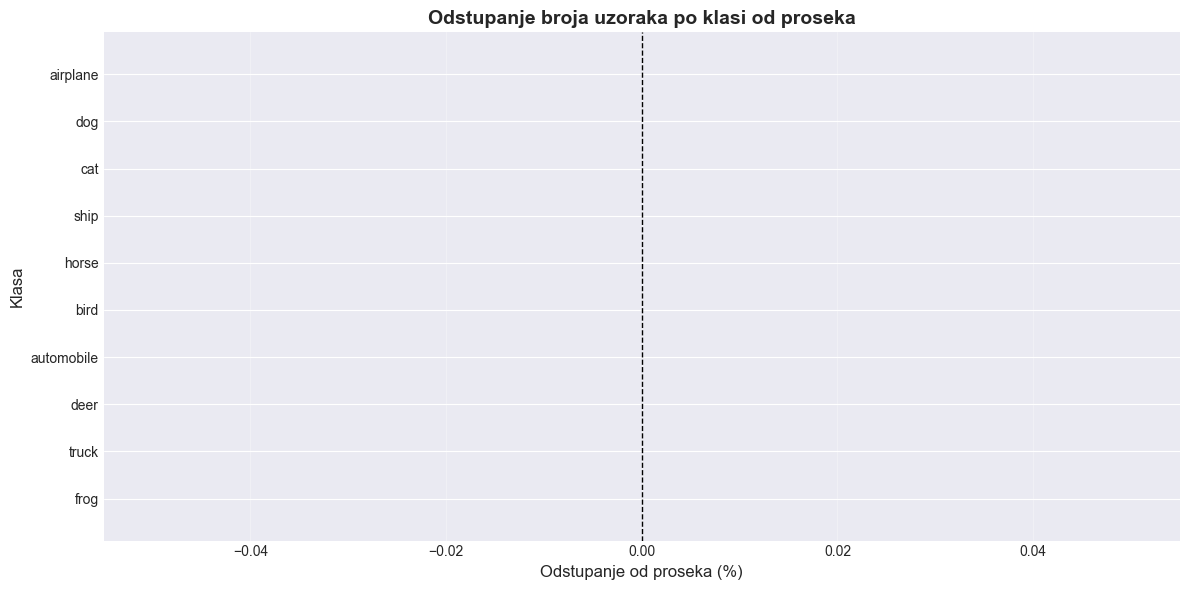

In [ ]:
#Analiza balansiranosti
class_counts = train_df_clean['label'].value_counts()
balance_ratio = class_counts.max() / class_counts.min()

print(f"Odnos najzastupljenije i najređe klase: {balance_ratio:.2f}")

if balance_ratio < 1.5:
    print("Dataset je dobro balansiran")
elif balance_ratio < 3:
    print("Dataset je umereno nebalansiran")
else:
    print("Dataset je značajno nebalansiran")

#Vizualizacija odstupanja od proseka
mean_count = class_counts.mean()
deviations = ((class_counts - mean_count) / mean_count * 100).sort_values()

plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'green' for x in deviations.values]
plt.barh(range(len(deviations)), deviations.values, color=colors, alpha=0.7)
plt.yticks(range(len(deviations)), deviations.index)
plt.xlabel('Odstupanje od proseka (%)', fontsize=12)
plt.ylabel('Klasa', fontsize=12)
plt.title('Odstupanje broja uzoraka po klasi od proseka', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("analysis_result/class_deviation_from_mean.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza svojstava slika

In [10]:
#Analiza slika
image_analysis = pipeline.analyze_image_properties(n_samples=500)

print("\n" + "="*60)
print("ANALIZA SVOJSTAVA SLIKA")
print("="*60)

print(f"\nAnalizirano slika: {image_analysis['samples_analyzed']}")
print(f"\nDimenzije slika:")
print(f"  - Najčešća dimenzija: {image_analysis['most_common_dimension']}")
print(f"  - Jedinstvene dimenzije: {image_analysis['unique_dimensions']}")

print(f"\nStatistika vrednosti piksela:")
for key, value in image_analysis['pixel_value_stats'].items():
    print(f"  - {key}: {value:.2f}")


Analiza svojstava slika (uzorak od 500)...
Analiza završena
  - Najčešća dimenzija: (32, 32)
  - Prosečna vrednost piksela: 120.56

ANALIZA SVOJSTAVA SLIKA

Analizirano slika: 500

Dimenzije slika:
  - Najčešća dimenzija: (32, 32)
  - Jedinstvene dimenzije: [(32, 32)]

Statistika vrednosti piksela:
  - mean: 120.56
  - std: 55.26
  - min_mean: 30.33
  - max_mean: 225.55


### Vizuelizacija uzoraka slika


Učitavanje 5 slika po klasi...
Učitano 50 slika


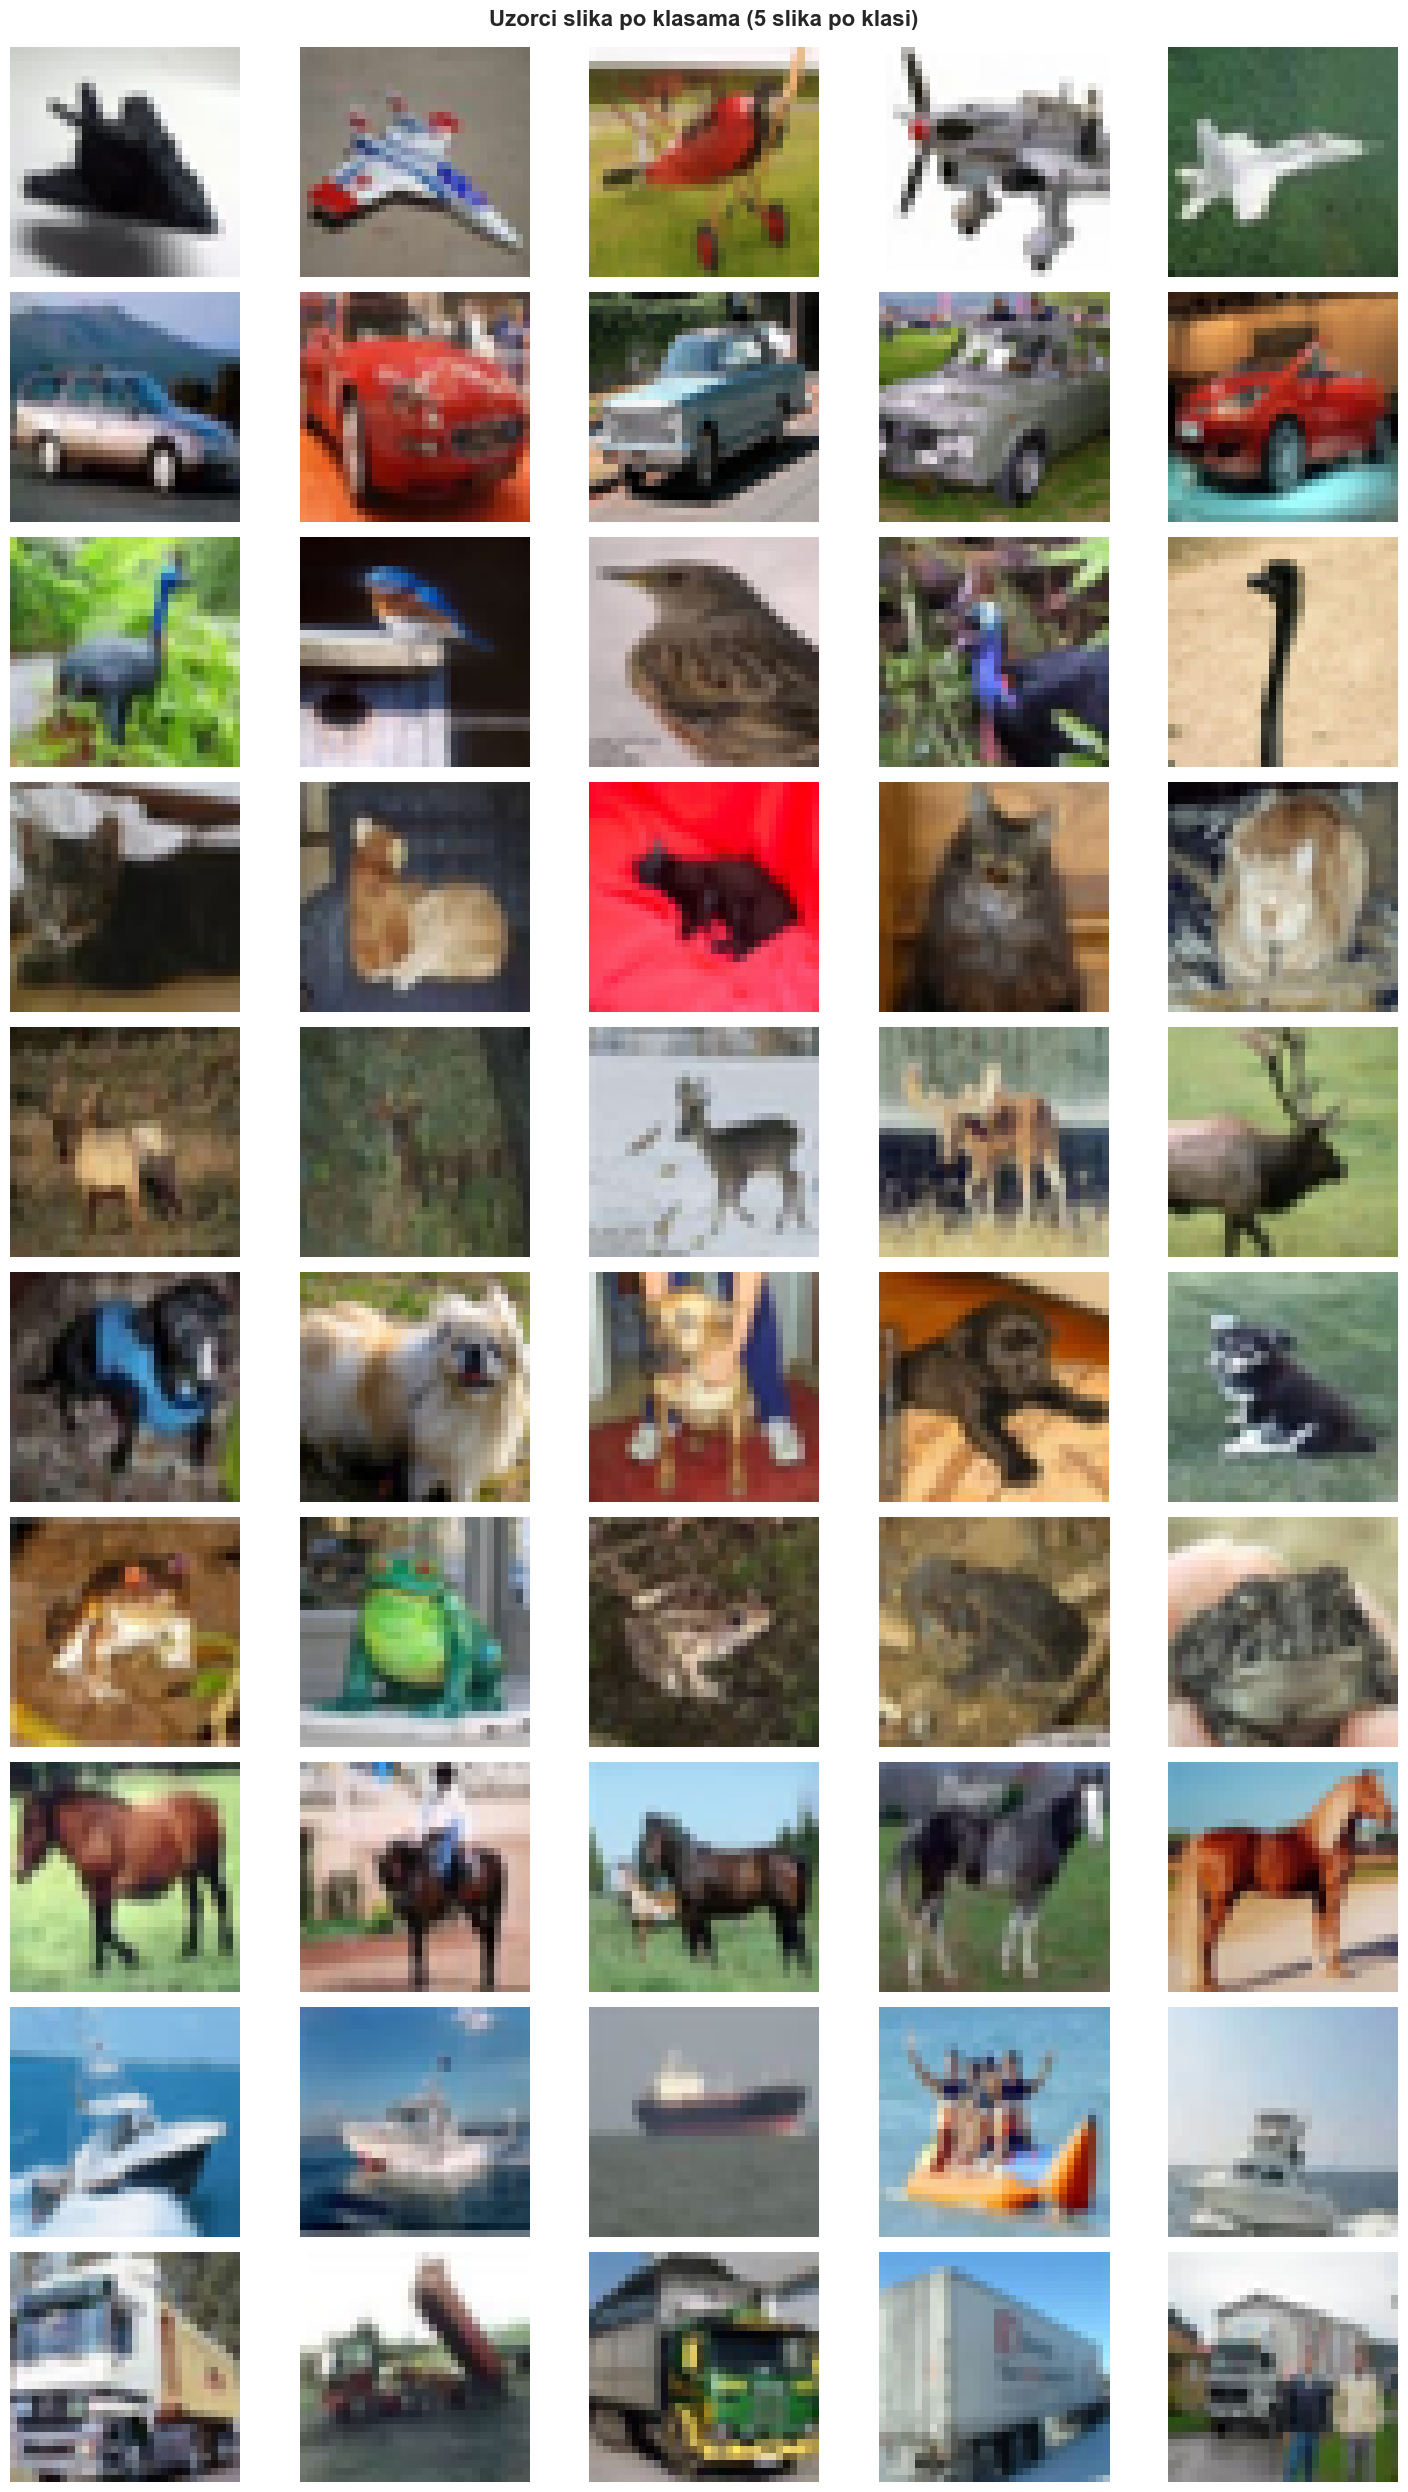

In [11]:
#Ucitavanje uzoraka slika
samples = pipeline.load_sample_images(n_samples=5)

#Prikaz po 5 slika za svaku klasu
fig, axes = plt.subplots(10, 5, figsize=(15, 25))
fig.suptitle('Uzorci slika po klasama (5 slika po klasi)', fontsize=16, fontweight='bold', y=0.995)

idx = 0
for class_idx, class_name in enumerate(pipeline.classes):
    for col in range(5):
        if idx < len(samples):
            img, label = samples[idx]
            if label == class_name:
                axes[class_idx, col].imshow(img)
                axes[class_idx, col].axis('off')
                if col == 0:
                    axes[class_idx, col].set_ylabel(class_name, fontsize=12, fontweight='bold')
                idx += 1

plt.tight_layout()
plt.savefig("analysis_result/image_samples.png", dpi=300, bbox_inches="tight")
plt.show()

### Analiza distribucije piksela

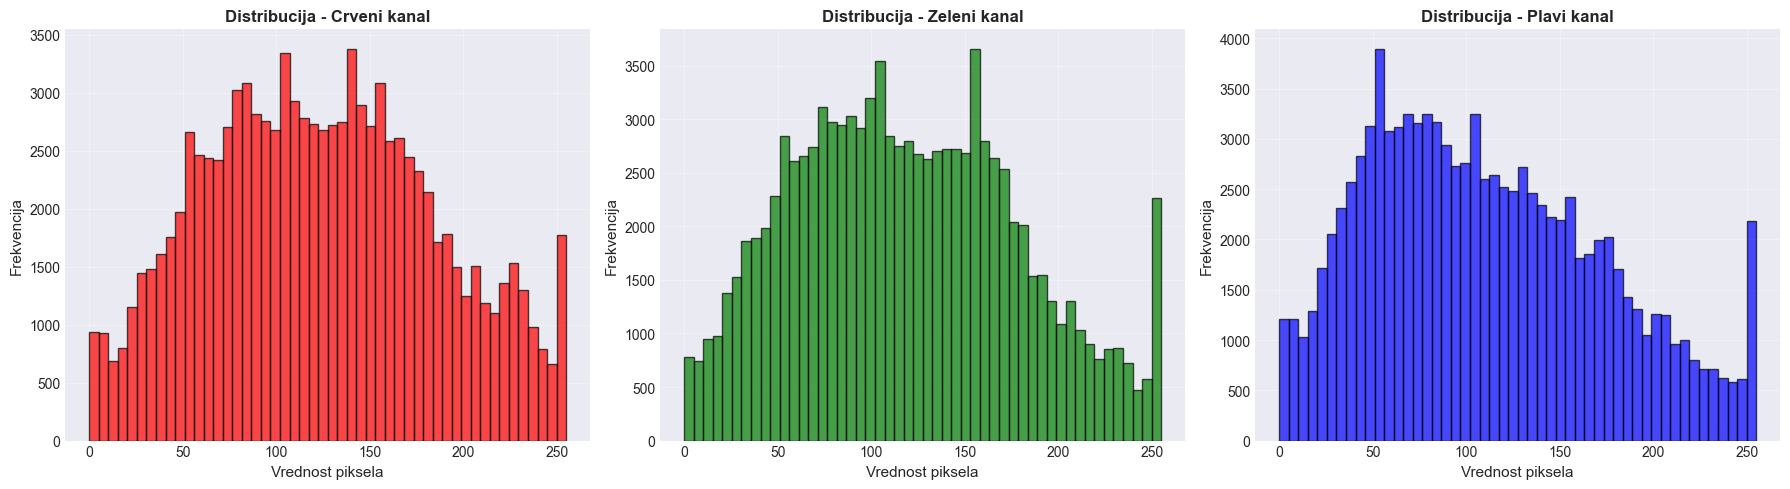


Statistika po RGB kanalima:

Crveni kanal:
  - Prosek: 123.87
  - Std. devijacija: 61.22
  - Min: 0
  - Max: 255

Zeleni kanal:
  - Prosek: 118.68
  - Std. devijacija: 60.14
  - Min: 0
  - Max: 255

Plavi kanal:
  - Prosek: 110.29
  - Std. devijacija: 62.29
  - Min: 0
  - Max: 255


In [12]:
#Učitavanje nekoliko slika za analizu piksela
sample_images = []
for img_id in train_df_clean['id'].sample(100):
    img_path = pipeline.train_dir / f"{img_id}.png"
    if img_path.exists():
        img = Image.open(img_path)
        sample_images.append(np.array(img))

#Analiza RGB kanala
if sample_images:
    all_pixels = np.concatenate([img.reshape(-1, 3) for img in sample_images])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['red', 'green', 'blue']
    channels = ['Crveni', 'Zeleni', 'Plavi']
    
    for i, (color, channel) in enumerate(zip(colors, channels)):
        axes[i].hist(all_pixels[:, i], bins=50, color=color, alpha=0.7, edgecolor='black')
        axes[i].set_xlabel('Vrednost piksela', fontsize=11)
        axes[i].set_ylabel('Frekvencija', fontsize=11)
        axes[i].set_title(f'Distribucija - {channel} kanal', fontsize=12, fontweight='bold')
        axes[i].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("analysis_result/pixel_value_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    #Statistika po kanalima
    print("\nStatistika po RGB kanalima:")
    for i, channel in enumerate(channels):
        print(f"\n{channel} kanal:")
        print(f"  - Prosek: {all_pixels[:, i].mean():.2f}")
        print(f"  - Std. devijacija: {all_pixels[:, i].std():.2f}")
        print(f"  - Min: {all_pixels[:, i].min()}")
        print(f"  - Max: {all_pixels[:, i].max()}")

### Korelaciona analiza izmedju klasa

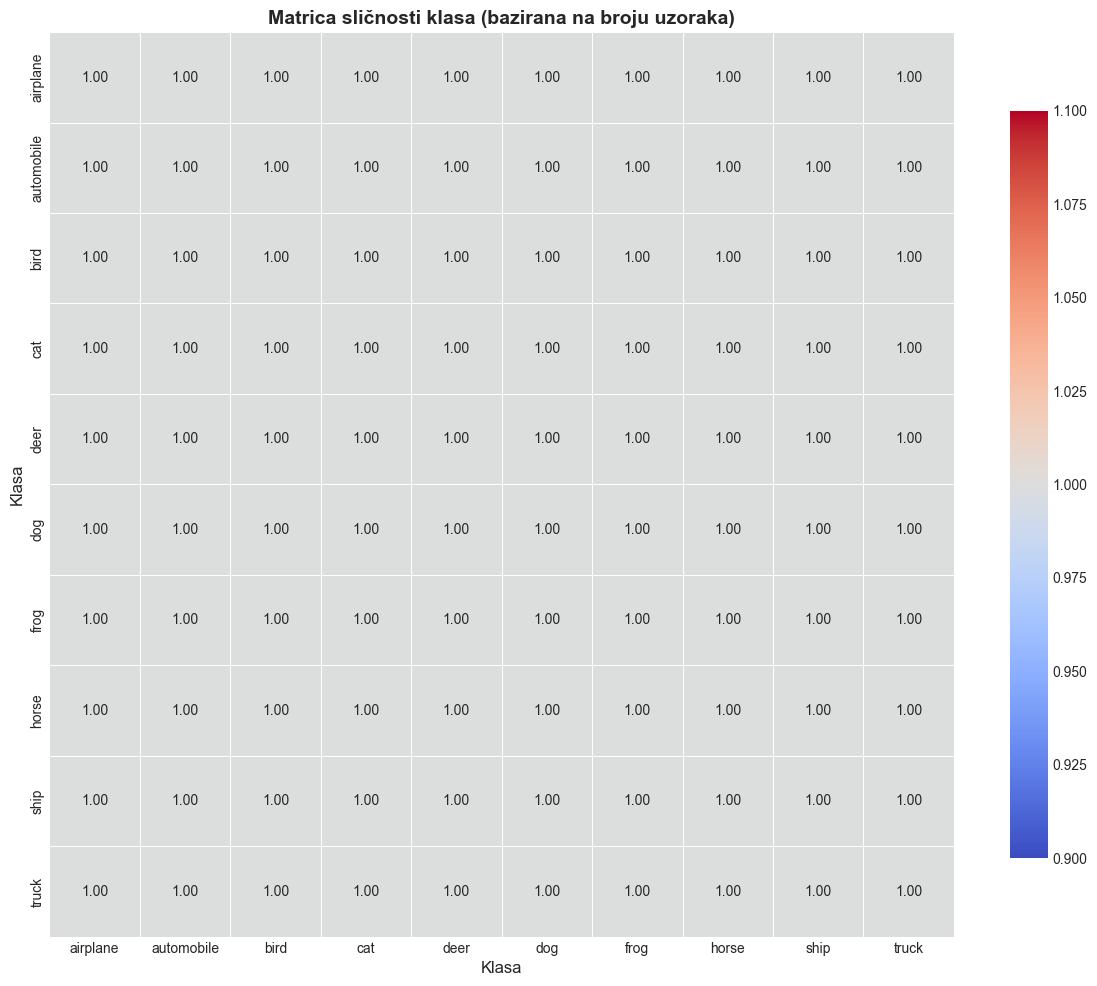

In [13]:
#Kreiranje matrice ko-pojave (koliko često se klase pojavljuju u sličnim proporcijama)
#Ovo je ilustrativna analiza - za pravu korelaciju bi trebalo analizirati feature-e slika

class_counts = train_df_clean['label'].value_counts()
class_matrix = pd.DataFrame(index=pipeline.classes, columns=pipeline.classes, dtype=float)

#Popunjavanje matrice sa normalizovanim brojevima
for i, class1 in enumerate(pipeline.classes):
    for j, class2 in enumerate(pipeline.classes):
        if i == j:
            class_matrix.loc[class1, class2] = 1.0
        else:
            #Sličnost bazirana na broju uzoraka
            count1 = class_counts.get(class1, 0)
            count2 = class_counts.get(class2, 0)
            similarity = 1 - abs(count1 - count2) / max(count1, count2)
            class_matrix.loc[class1, class2] = similarity

class_matrix = class_matrix.astype(float)

#Vizualizacija
plt.figure(figsize=(12, 10))
sns.heatmap(class_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrica sličnosti klasa (bazirana na broju uzoraka)', fontsize=14, fontweight='bold')
plt.xlabel('Klasa', fontsize=12)
plt.ylabel('Klasa', fontsize=12)
plt.tight_layout()
plt.savefig("analysis_result/class_similarity_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Cuvanje obradjenih podataka

In [14]:
# Čuvanje očišćenih podataka
pipeline.save_processed_data('analysis_result/processed_train_labels.csv')

print("\nObrađeni podaci sačuvani u 'processed_train_labels.csv'")


Čuvanje obrađenih podataka u analysis_result/processed_train_labels.csv...
Podaci sačuvani

Obrađeni podaci sačuvani u 'processed_train_labels.csv'
